### Brief description of the received dataset



In [2]:
!pip install --upgrade google-cloud-bigquery

from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import (
    pearsonr,
    shapiro,
    levene,
    mannwhitneyu,
    kruskal
)

from statsmodels.stats.proportion import proportions_ztest

from google.colab import auth
from google.cloud import bigquery


# Authentication
auth.authenticate_user()

# Creating a client for BigQuery
client = bigquery.Client(project="data-analytics-mate")

# SQL-query
query = """
SELECT
    s.date,
    s.ga_session_id AS session_id,
    sp.continent,
    sp.country,
    sp.device AS device_type,
    sp.browser,
    sp.mobile_model_name AS device_model,
    sp.operating_system AS os,
    sp.language AS browser_language,
    sp.name AS traffic_source,
    sp.medium AS traffic_medium,
    sp.channel AS traffic_channel,
    ac.account_id,
    a.is_verified AS is_email_verified,
    a.is_unsubscribed AS is_unsubscribed,
    o.ga_session_id AS sessions_with_orders,
    p.category AS product_category,
    p.name AS product_name,
    p.price AS price,
    p.short_description AS product_description
FROM
    `DA.order` o
FULL JOIN
    `DA.session` s
ON
    o.ga_session_id = s.ga_session_id
LEFT JOIN
    `DA.session_params` sp
ON
    s.ga_session_id = sp.ga_session_id
LEFT JOIN
    `DA.account_session` ac
ON
    s.ga_session_id = ac.ga_session_id
LEFT JOIN
    `DA.account` a
ON
    ac.account_id = a.id
LEFT JOIN
    `DA.product` p
ON
    o.item_id = p.item_id
"""

# Query execution
query_job = client.query(query)  # Executing an SQL query
results = query_job.result()  # Waiting for the query to complete

# Converting results to a DataFrame without BigQuery Storage API
df = results.to_dataframe(create_bqstorage_client=False)

# Result output
df.head()


,date,session_id,continent,country,device_type,browser,device_model,os,browser_language,traffic_source,traffic_medium,traffic_channel,account_id,is_email_verified,is_unsubscribed,sessions_with_orders,product_category,product_name,price,product_description
0,2020-11-06,7799937037,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,(referral),referral,Paid Search,<NA>,<NA>,<NA>,7799937037,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,2020-11-10,4020421879,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(direct),(none),Direct,653378,1,0,4020421879,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,2020-11-24,6717382496,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(referral),referral,Social Search,<NA>,<NA>,<NA>,6717382496,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2020-11-26,2093497337,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(direct),(none),Direct,<NA>,<NA>,<NA>,2093497337,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,2020-12-03,9506718330,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,(referral),referral,Paid Search,<NA>,<NA>,<NA>,9506718330,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"


In [3]:

# Brief description of the received dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   date                  349545 non-null  dbdate 
 1   session_id            349545 non-null  Int64  
 2   continent             349545 non-null  object 
 3   country               349545 non-null  object 
 4   device_type           349545 non-null  object 
 5   browser               349545 non-null  object 
 6   device_model          349545 non-null  object 
 7   os                    349545 non-null  object 
 8   browser_language      235279 non-null  object 
 9   traffic_source        349545 non-null  object 
 10  traffic_medium        349545 non-null  object 
 11  traffic_channel       349545 non-null  object 
 12  account_id            27945 non-null   Int64  
 13  is_email_verified     27945 non-null   Int64  
 14  is_unsubscribed       27945 non-null   Int64  
 15  

total number of columns: 20

number of numeric columns: 6 (session_id, account_id, is_email_verified, is_unsubscribed, sessions_with_orders, price)

number of categorical columns: 13 (continent , country , device_type , browser , device_model , os , browser_language , traffic_source , traffic_medium , traffic_channel , product_category , product_name , product_description)

number of datetime columns: 1 (date)





In [4]:
print(f"Number of unique sessions: {df['session_id'].nunique()}")
print(f"Number of unique users: {df['account_id'].nunique()}")
print(f"Period: from {df['date'].min()} to {df['date'].max()}")


Number of unique sessions: 349545
Number of unique users: 27945
Period: from 2020-11-01 to 2021-01-31


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
account_id,321600,92.01
is_unsubscribed,321600,92.01
is_email_verified,321600,92.01
product_category,316007,90.41
sessions_with_orders,316007,90.41
price,316007,90.41
product_name,316007,90.41
product_description,316007,90.41
browser_language,114266,32.69


Which columns have more missing values, and why?

The largest number of missing values ​​(92%) is in the columns related to accounts (account_id, is_email_verified, is_unsubscribed), since most users use the site without logging in or registering.

The columns related to order details (sessions_with_orders, product_category, price, product_name, product_description) are in second place in terms of the number of missing values ​​(90%). This is explained by the lack of relevant information in sessions without orders.

And last of all (~33% of missing values) is in the column with the browser language. This can be explained by the fact that not all browsers share this information. Or by the fact that the browser language could be outside the sample of languages ​​for which information was collected (for example, less popular languages).



### Sales and order analysis


In [6]:
# Top 3 continents by sales
top_continents_by_sales = df.groupby("continent")["price"].sum().sort_values(ascending=False)
display(top_continents_by_sales.head(3))


,price
continent,
Americas,17665280.0
Asia,7601298.3
Europe,5934624.2


In [7]:
# Top 3 continents by number of orders
top_continents_by_orders = df.groupby("continent")["sessions_with_orders"].count().sort_values(ascending=False)
display(top_continents_by_orders.head(3))


,sessions_with_orders
continent,
Americas,18553
Asia,7950
Europe,6261


In [8]:
# Top 5 countries by sales
top_countries_by_sales = df.groupby("country")["price"].sum().sort_values(ascending=False)
display(top_countries_by_sales.head(5))


,price
country,
United States,13943553.9
India,2809762.0
Canada,2437921.0
United Kingdom,938317.9
France,710692.8


In [9]:
# Top 5 countries by number of orders
top_countries_by_orders = df.groupby("country")["sessions_with_orders"].count().sort_values(ascending=False)
display(top_countries_by_orders.head(5))


,sessions_with_orders
country,
United States,14673
India,3029
Canada,2560
United Kingdom,1029
France,678


In [10]:
# Top 10 product categories by total sales
top_by_product_categry = df.groupby("product_category")["price"].sum().sort_values(ascending=False)
display(top_by_product_categry.head(10))


,price
product_category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5
Outdoor furniture,2142222.2
Tables & desks,1790307.5
Chests of drawers & drawer units,906562.5
Bar furniture,735503.0


In [11]:
# Top 10 product categories in the country with the highest sales
top_products_in_usa = df[df["country"] == "United States"].groupby("product_category")["price"].sum().sort_values(ascending=False)
display(top_products_in_usa.head(10))


,price
product_category,
Sofas & armchairs,3707144.5
Chairs,2619773.8
Beds,2213058.0
Bookcases & shelving units,1567606.9
Cabinets & cupboards,994545.5
Outdoor furniture,929245.2
Tables & desks,777865.0
Chests of drawers & drawer units,382388.0
Bar furniture,330805.0


Is the situation different from the general situation?

No, the top 10 products in the country with the highest sales are no different from the general top 10 products.


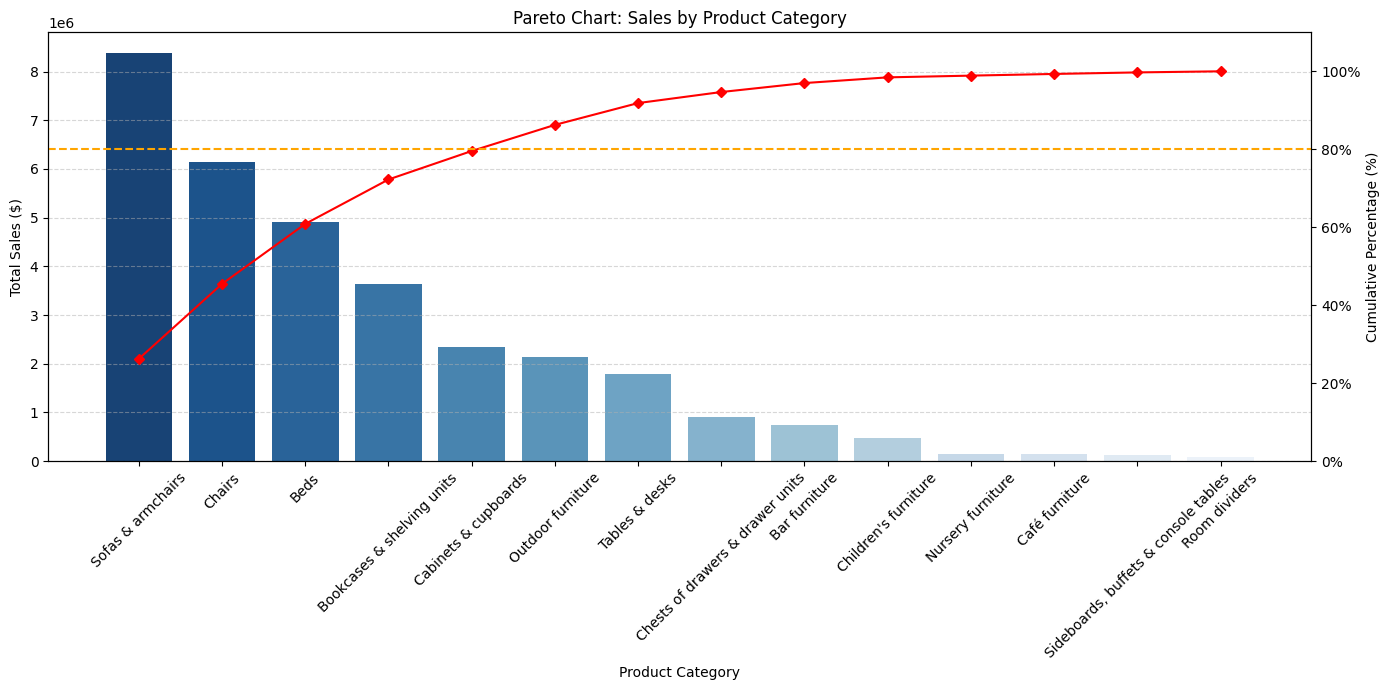

In [12]:
# Let's build a Pareto Chart.
# It will show us which product categories bring in the most revenue,
# as well as the cumulative percentage of revenue from each subsequent product category out of the total revenue.


# 1. Data preparation: group sales by categories
pareto_df = df.groupby("product_category")["price"].sum().reset_index()
pareto_df = pareto_df.sort_values(by="price", ascending=False)

# 2. Calculation of cumulative percentage
pareto_df["cum_percentage"] = pareto_df["price"].cumsum() / pareto_df["price"].sum() * 100

# 3. Visualization
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart for sales
sns.barplot(x="product_category", y="price", data=pareto_df, ax=ax1, palette="Blues_r", hue="product_category", legend=False)
ax1.set_xlabel("Product Category")
ax1.set_ylabel("Total Sales ($)")
ax1.tick_params(axis="x", rotation=45)

# Second axis for the cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(pareto_df["product_category"], pareto_df["cum_percentage"], color="red", marker="D", ms=5, label="Cumulative %")
ax2.axhline(80, color="orange", linestyle="--", label="80% Cut-off") # 80% line

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 110)

# Formatting the axis as a percentage
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.title("Pareto Chart: Sales by Product Category")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()


The first 5 categories (Sofas & armchairs, Chairs, Beds, Bookcases, Cabinets) generate the lion's share of revenue. We see that the red line crosses the 80% threshold for about 5 categories. This means that about 36% of our categories (out of 14 available) generate 80% of total revenue.


In [13]:
# Sales analysis across device types
total_sales = df["price"].sum()


sales_by_device_type = df.groupby(["device_type"])["price"].sum().reset_index()
sales_by_device_type["percentage_of_total_sales"] = (sales_by_device_type["price"] / total_sales * 100).round(2)

display(sales_by_device_type.sort_values("percentage_of_total_sales", ascending=False))


,device_type,price,percentage_of_total_sales
0,desktop,18864039.0,59.00
1,mobile,12384225.8,38.73
2,tablet,723466.3,2.26


In [14]:
# Sales analysis by device types and models (as a % of total sales)
sales_by_device = df.groupby(["device_type", "device_model"])["price"].sum().reset_index()
sales_by_device["percentage_of_total_sales"] = (sales_by_device["price"] / total_sales * 100).round(2)

display(sales_by_device.sort_values("percentage_of_total_sales", ascending=False))

,device_type,device_model,price,percentage_of_total_sales
1,desktop,Chrome,8899523.9,27.84
5,desktop,Safari,6490467.1,20.30
11,mobile,iPhone,6420776.3,20.08
6,mobile,<Other>,5735073.6,17.94
2,desktop,ChromeBook,1830458.7,5.73
3,desktop,Edge,696877.3,2.18
0,desktop,<Other>,525645.1,1.64
13,tablet,iPad,448854.2,1.40
4,desktop,Firefox,421066.9,1.32
12,tablet,<Other>,274612.1,0.86


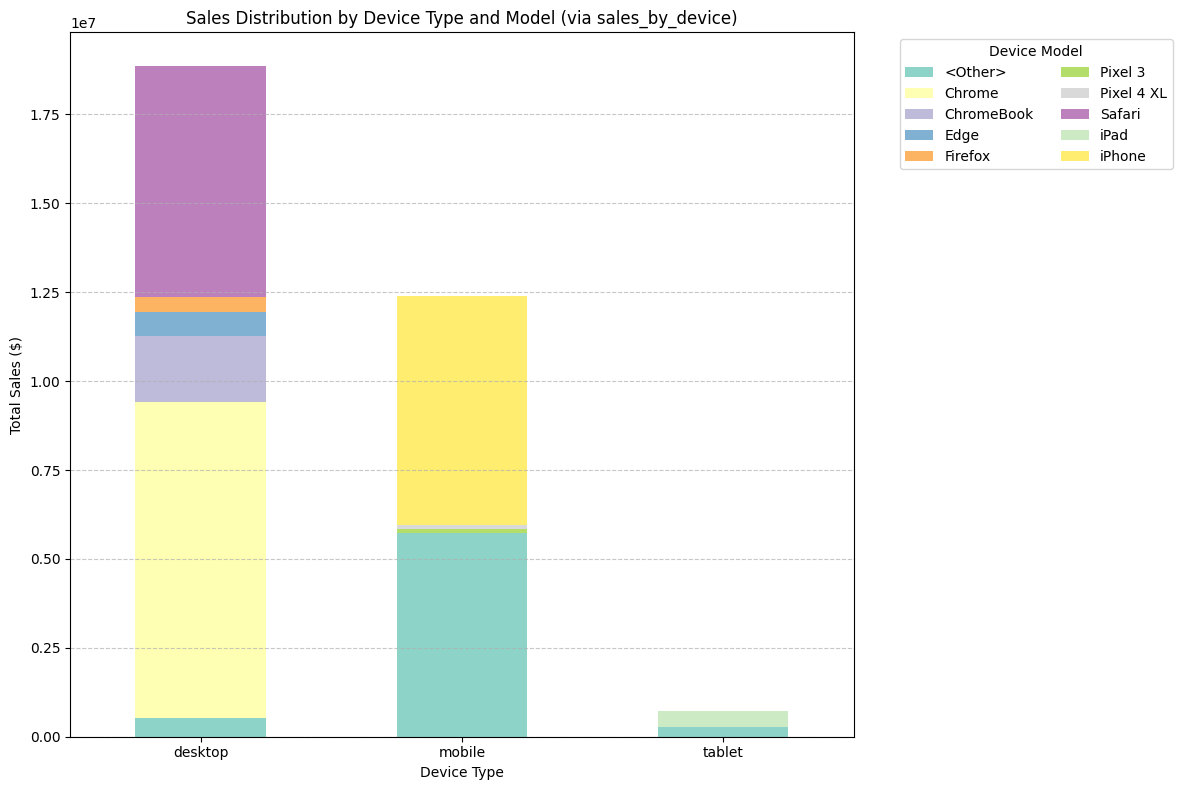

In [15]:
# 1. set_index creates a hierarchy
# 2. ["price"] selects the desired data
# 3. unstack() unfolds the models in columns
device_model_sales_v2 = sales_by_device.set_index(["device_type", "device_model"])["price"].unstack().fillna(0)

# Visualization
device_model_sales_v2.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="Set3")

plt.title("Sales Distribution by Device Type and Model (via sales_by_device)")
plt.xlabel("Device Type")
plt.ylabel("Total Sales ($)")
plt.legend(title="Device Model", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Sales analysis by device type shows that the majority of sales to our store come from **desktop devices** — **59%**, another **39%** of sales come from **mobile devices** and only 2% from tablets.

Analysis by device type shows that the top 5 sales by device model and 91.98% of all sales are Chrome desktop, Safari desktop, iPhone mobile, Other mobile (may be high due to the large number of devices for which a separate device_model is not allocated) and ChromeBook desktop.



In [16]:
# Sales by traffic source (as % of total sales)
sales_by_traffic_source = df.groupby(["traffic_source"])["price"].sum().reset_index()
sales_by_traffic_source["percentage_of_total_sales"] = (sales_by_traffic_source["price"] / total_sales *100).round(2)

display(sales_by_traffic_source.sort_values("percentage_of_total_sales", ascending=False))


,traffic_source,price,percentage_of_total_sales
2,(organic),10935239.9,34.20
1,(direct),7494923.4,23.44
4,<Other>,5897375.6,18.45
3,(referral),5641855.2,17.65
0,(data deleted),2002337.0,6.26


In [17]:

verified_percentage = (df["is_email_verified"] == 1).sum() / df["account_id"].nunique() * 100
print(f"Registered users who have confirmed their email address are {verified_percentage:.2f}%")


Registered users who have confirmed their email address are 71.70%


In [18]:
unsubscribed_percentage = (df["is_unsubscribed"] == 1).sum() / df["account_id"].nunique() * 100
print(f"Registered users who have unsubscribed from the newsletter are {unsubscribed_percentage:.2f}%")


Registered users who have unsubscribed from the newsletter are 16.94%


In [19]:
# is the behavior (in terms of sales) different between those who unsubscribed from the newsletter and those who are still subscribed?
unsubscribed_sales = df[df["is_unsubscribed"] == 1]["price"].sum()
subscribed_sales = df[df["is_unsubscribed"] == 0]["price"].sum()
print(f"Total sales of unsubscribed users: {unsubscribed_sales:.2f}")
print(f"Total sales of subscribed users: {subscribed_sales:.2f}")



Total sales of unsubscribed users: 431721.60
Total sales of subscribed users: 2150796.90


In [20]:
# Which countries have the most registered users?
registrations_by_country = df.groupby(["country"])["account_id"].nunique().sort_values(ascending=False)
display(registrations_by_country.head(10))


,account_id
country,
United States,12384
India,2687
Canada,2067
United Kingdom,859
France,553
Spain,536
Taiwan,500
China,490
Germany,490


In [21]:
# total number of sessions and number of sessions with orders
total_sessions_count = df["session_id"].nunique()
sessions_with_orders_count = df[df["sessions_with_orders"].notna()]["session_id"].nunique()

comparison_data = pd.DataFrame({
    "Session type": ["All sessions", "Sessions with orders"],
    "Amount": [total_sessions_count, sessions_with_orders_count]
})

display(comparison_data)


,Session type,Amount
0,All sessions,349545
1,Sessions with orders,33538


/tmp/ipykernel_1659/1602007308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Session type", y="Amount", data=comparison_data, palette="muted")


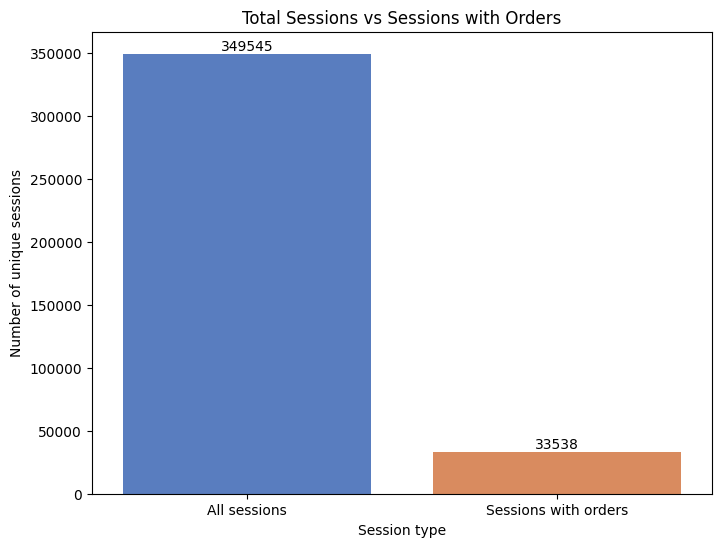

Overall conversion rate: 9.59%


In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Session type", y="Amount", data=comparison_data, palette="muted")
plt.title("Total Sessions vs Sessions with Orders")
plt.ylabel("Number of unique sessions")

# Add value labels to the columns
for i, val in enumerate(comparison_data["Amount"]):
    plt.text(i, val, f"{val}", ha="center", va="bottom")

plt.show()

conversion_rate = (sessions_with_orders_count / total_sessions_count) * 100
print(f"Overall conversion rate: {conversion_rate:.2f}%")


### Sales dynamics analysis

In [23]:
# total sales for each date

daily_sales = df.groupby(["date"])["price"].sum()

display(daily_sales.head())


,price
date,
2020-11-01,244292.5
2020-11-02,355506.8
2020-11-03,498979.6
2020-11-04,339187.1
2020-11-05,391276.6


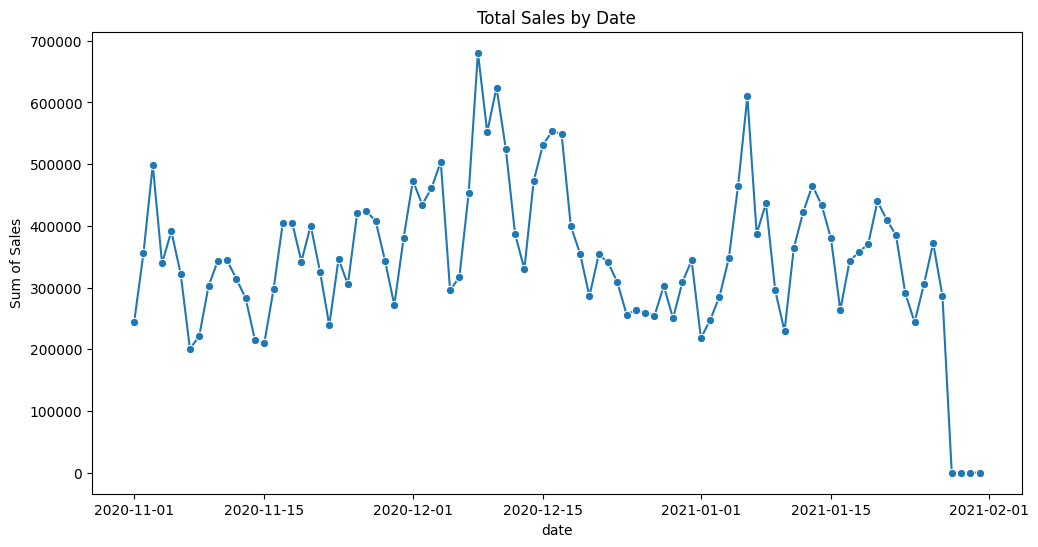

In [24]:
# visualization of overall sales dynamics
daily_sales_df = daily_sales.reset_index()



plt.figure(figsize=(12, 6))
sns.lineplot(x="date", y="price", data=daily_sales_df, marker='o')
plt.title("Total Sales by Date")
plt.ylabel("Sum of Sales")

plt.show()

**Is there any seasonality in sales?**

Yes, the graph clearly shows weekly fluctuations, as well as the impact of the New Year period.

At the end of the graph, sales drop to zero. Apparently, there is no data in the last collection periods.

In [25]:
# Daily sales by continent

daily_sales_by_continent = df.groupby(["date", "continent"])["price"].sum()

display(daily_sales_by_continent.head(10))


date        continent
2020-11-01  (not set)         0.0
            Africa         1184.0
            Americas     132002.5
            Asia          63823.0
            Europe        46908.0
            Oceania         375.0
2020-11-02  (not set)        75.0
            Africa         3781.0
            Americas     193861.0
            Asia          79370.0
Name: price, dtype: float64

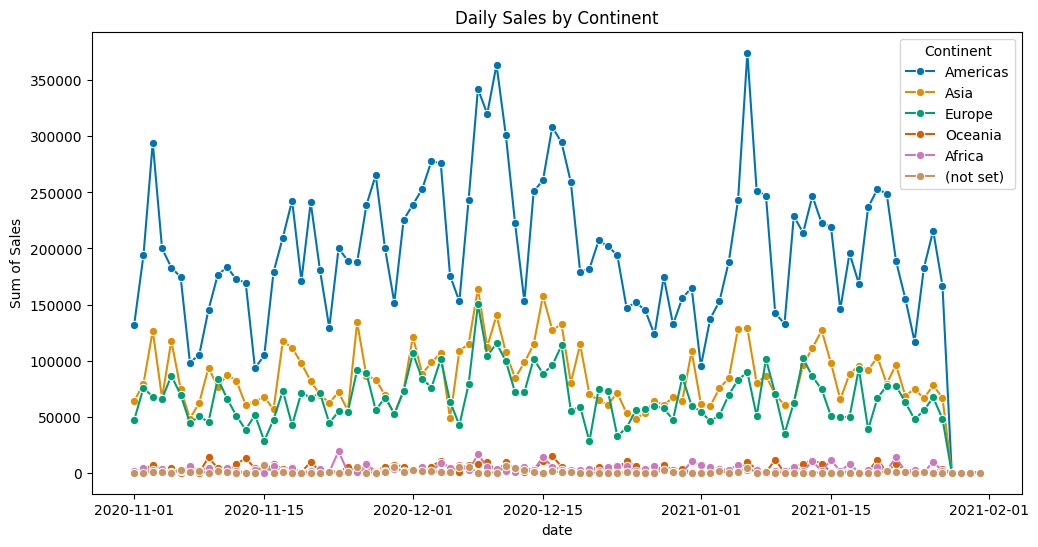

In [26]:
daily_sales_by_continent_df = daily_sales_by_continent.reset_index()

# Calculate total sales per continent to order the legend
continent_order = daily_sales_by_continent_df.groupby("continent")["price"].sum().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.lineplot(x="date", y="price", hue="continent", hue_order=continent_order, marker='o', data=daily_sales_by_continent_df, palette="colorblind")
plt.title("Daily Sales by Continent")
plt.ylabel("Sum of Sales")
plt.legend(title="Continent")

plt.show()

In [27]:
# analysis of sales dynamics by traffic channels

daily_sales_by_traffic_source = df.groupby(["date", "traffic_source"])["price"].sum()

display(daily_sales_by_traffic_source.head(10))


date        traffic_source
2020-11-01  (data deleted)      4903.0
            (direct)           54669.5
            (organic)          86081.0
            (referral)         44450.0
            <Other>            54189.0
2020-11-02  (data deleted)     24575.0
            (direct)           81561.5
            (organic)         133845.8
            (referral)         43236.0
            <Other>            72288.5
Name: price, dtype: float64

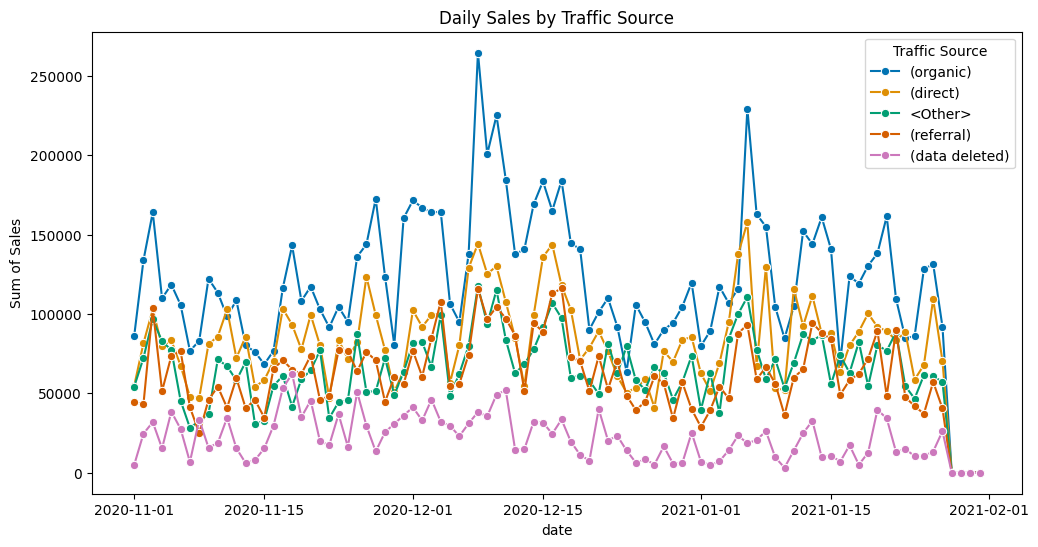

In [28]:
daily_sales_by_traffic_source_df = daily_sales_by_traffic_source.reset_index()

# Calculate total sales per traffic source to order the legend
traffic_source_order = daily_sales_by_traffic_source_df.groupby("traffic_source")["price"].sum().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.lineplot(x="date", y="price", hue="traffic_source", hue_order=traffic_source_order, marker='o', data=daily_sales_by_traffic_source_df, palette="colorblind")
plt.title("Daily Sales by Traffic Source")
plt.ylabel("Sum of Sales")
plt.legend(title="Traffic Source")

plt.show()


In [29]:
# analysis of sales dynamics by device type

daily_sales_by_device_type = df.groupby(["date", "device_type"])["price"].sum()

display(daily_sales_by_device_type.head(10))


date        device_type
2020-11-01  desktop        144445.0
            mobile          99698.5
            tablet            149.0
2020-11-02  desktop        206727.3
            mobile         137269.5
            tablet          11510.0
2020-11-03  desktop        304473.8
            mobile         180602.8
            tablet          13903.0
2020-11-04  desktop        212227.7
Name: price, dtype: float64

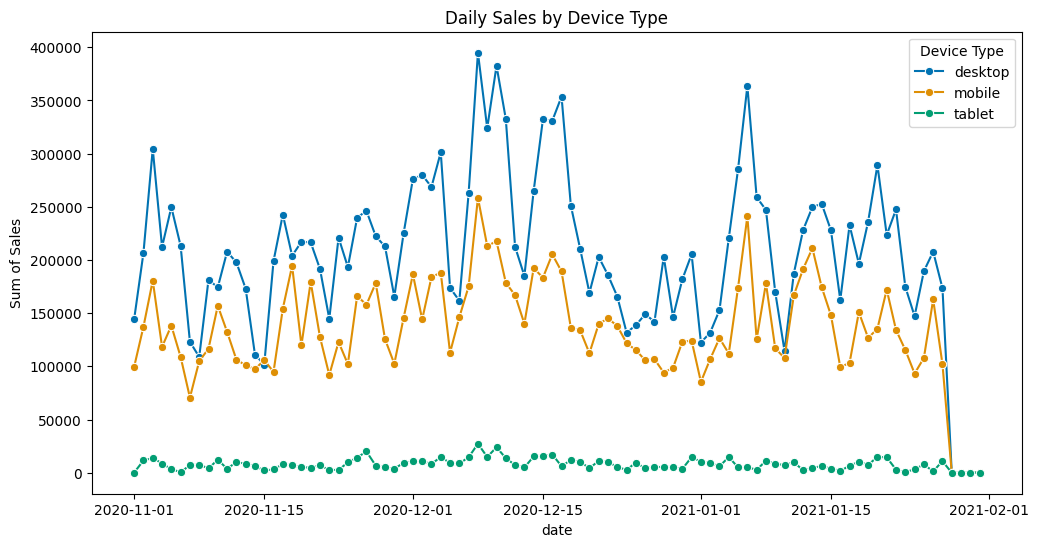

In [30]:
daily_sales_by_device_type_df = daily_sales_by_device_type.reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x="date", y="price", hue="device_type", marker='o', data=daily_sales_by_device_type_df, palette="colorblind")
plt.title("Daily Sales by Device Type")
plt.ylabel("Sum of Sales")
plt.legend(title="Device Type")

plt.show()


**CONCLUSIONS**

Total Sales by Date graph clearly shows weekly fluctuations, as well as the impact of the New Year period.

Daily Sales by Continent, Daily Sales by Traffic Source, Daily Sales by Device Type not only identify leaders in dynamics, but also demonstrate seasonal mutual trends across continents, across different traffic sources, and across different device types.

### Summary tables

In [31]:
# number of sessions by traffic channels and device types
sessions_by_channel_and_device = df.groupby(['traffic_channel', 'device_type'])['session_id'].nunique().unstack().fillna(0)

display(sessions_by_channel_and_device)


device_type,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [32]:
# total sales by product category (top 10 categories) in different countries (top 5 countries)
top_10_product_categories = df.groupby("product_category")["price"].sum().nlargest(10).index
top_5_countries = df.groupby("country")["price"].sum().nlargest(5).index

filtered_df = df[df["product_category"].isin(top_10_product_categories) & df["country"].isin(top_5_countries)]

pivot_table_sales = filtered_df.pivot_table(index='product_category', columns='country', values='price', aggfunc='sum').fillna(0)

display(pivot_table_sales)


country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


In [33]:
# conversion rate by traffic channels and device types
session_counts_by_channel_device = df.groupby(['traffic_channel', 'device_type']).agg(
    total_sessions=('session_id', 'nunique'),
    sessions_with_orders_count=('sessions_with_orders', lambda x: x.notna().sum())
).reset_index()

display(session_counts_by_channel_device)

,traffic_channel,device_type,total_sessions,sessions_with_orders_count
0,Direct,desktop,47825,4655
1,Direct,mobile,31745,2985
2,Direct,tablet,1812,160
3,Organic Search,desktop,72622,7011
4,Organic Search,mobile,49014,4655
5,Organic Search,tablet,2789,255
6,Paid Search,desktop,55167,5261
7,Paid Search,mobile,37034,3574
8,Paid Search,tablet,2140,207
9,Social Search,desktop,16288,1594


In [34]:
conversion_rate_by_channel_device = session_counts_by_channel_device.copy()
conversion_rate_by_channel_device['conversion_rate'] = (conversion_rate_by_channel_device['sessions_with_orders_count'] / conversion_rate_by_channel_device['total_sessions']) * 100

pivot_conversion_rate = conversion_rate_by_channel_device.pivot_table(
    index='traffic_channel',
    columns='device_type',
    values='conversion_rate'
).fillna(0)

display(pivot_conversion_rate.style.format('{:.2f}%'))

device_type,desktop,mobile,tablet
traffic_channel,,,
Direct,9.73%,9.40%,8.83%
Organic Search,9.65%,9.50%,9.14%
Paid Search,9.54%,9.65%,9.67%
Social Search,9.79%,9.69%,8.93%
Undefined,9.43%,9.83%,9.36%


## Statistical analysis of relationships.


### Correlation Analysis Between number of sessions and total sales

In [35]:
# number of sessions and total sales for each date
daily_sessions_cnt = df.groupby(["date"])["session_id"].nunique()

display(daily_sessions_cnt.head())

,session_id
date,
2020-11-01,2576
2020-11-02,3599
2020-11-03,5173
2020-11-04,4184
2020-11-05,3743


In [36]:
daily_data = pd.DataFrame({
    'sessions': daily_sessions_cnt,
    'sales': daily_sales
}).reset_index()
display(daily_data.head())

,date,sessions,sales
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


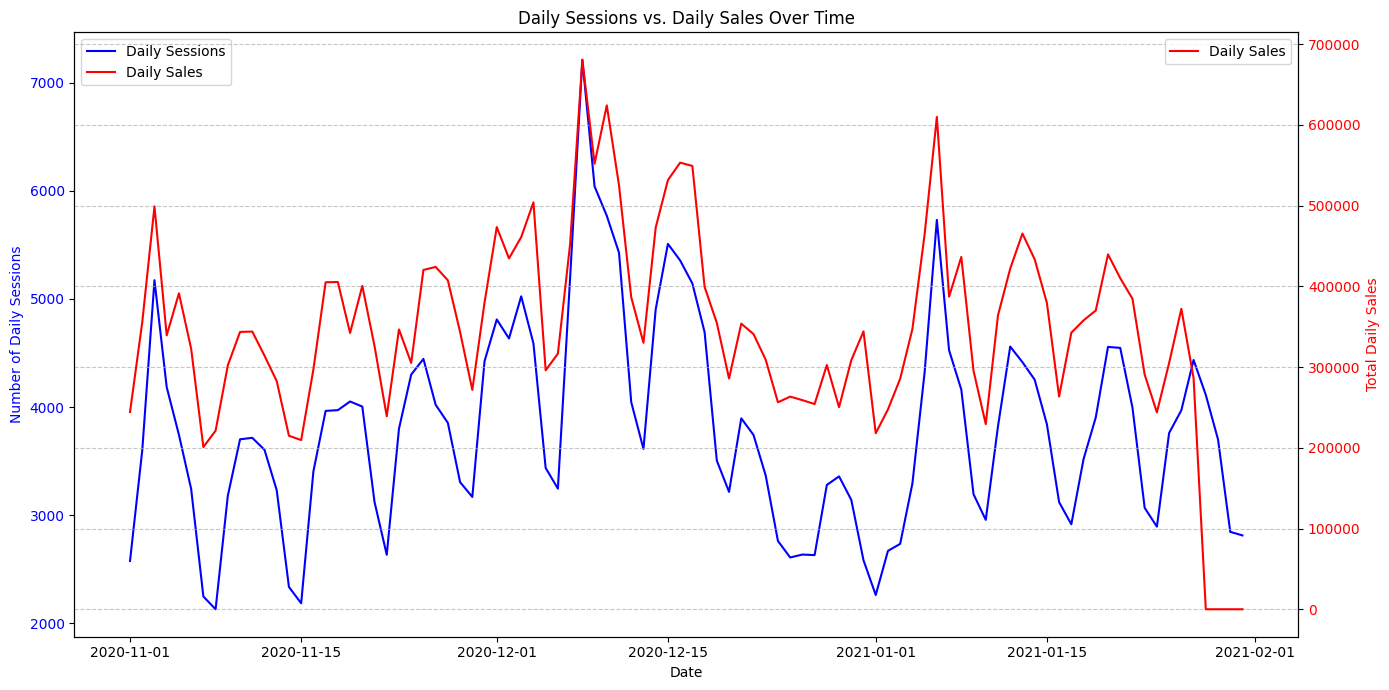

In [37]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot daily sessions on the primary y-axis
sns.lineplot(x='date', y='sessions', data=daily_data, ax=ax1, color='blue', label='Daily Sessions')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Daily Sessions', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis for daily sales
ax2 = ax1.twinx()
sns.lineplot(x='date', y='sales', data=daily_data, ax=ax2, color='red', label='Daily Sales')
ax2.set_ylabel('Total Daily Sales', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Daily Sessions vs. Daily Sales Over Time')
fig.tight_layout() # Adjust layout to prevent labels from overlapping

# Add legends for both lines
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles + handles2, labels + labels2, loc='upper left')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

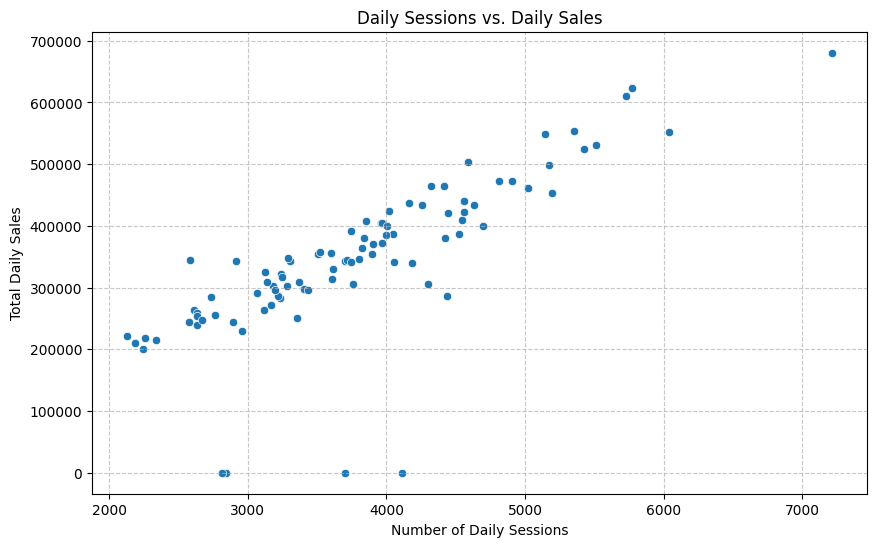

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sessions', y='sales', data=daily_data)
plt.title('Daily Sessions vs. Daily Sales')
plt.xlabel('Number of Daily Sessions')
plt.ylabel('Total Daily Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [39]:
# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(daily_data['sessions'], daily_data['sales'])

print(f"Pearson's correlation coefficient for sessions and sales: {correlation_coefficient:.2f}")
print(f"P-value: {p_value:.3f}")

Pearson's correlation coefficient for sessions and sales: 0.79
P-value: 0.000


**Correlation Analysis Between Daily Sessions and Sales**

**Pearson's Correlation Coefficient**: A value of **0.79** indicates:
* Positive relationship: As the number of sessions increases, sales tend to increase.
* Strength of relationship: A value close to 1 indicates a strong positive linear relationship.

**P-value**: A value below **0.001** is:
* Statistically significant: Since the p-value is less than the generally accepted significance level (e.g. 0.05), we can reject the null hypothesis that there is no linear relationship.
* Interpretation: This means that the observed correlation is not random and most likely reflects a real relationship between the number of sessions and sales.


### Analysis of sales correlation between the top 3 continents


In [40]:
# Sales correlation across continents
top_3_continents = top_continents_by_sales.head(3).index
df_top_continents = df[df['continent'].isin(top_3_continents)]

daily_sales_top_continents = df_top_continents.groupby(['date', 'continent'])['price'].sum().unstack().fillna(0)
display(daily_sales_top_continents.head())

continent,Americas,Asia,Europe
date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0


In [41]:
correlation_matrix = daily_sales_top_continents.corr(method='pearson')
display(correlation_matrix)

continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.792025,0.770586
Asia,0.792025,1.000000,0.768427
Europe,0.770586,0.768427,1.000000


In [42]:
# Calculate Pearson correlation coefficient and p-value
# for each pair of continents
for continent_1, continent_2 in combinations(daily_sales_top_continents.columns, 2):
    r, p_value = pearsonr(
        daily_sales_top_continents[continent_1],
        daily_sales_top_continents[continent_2]
    )

    print(
        f"{continent_1} vs {continent_2}: "
        f"r = {r:.3f}, p-value = {p_value:.3f}"
    )

Americas vs Asia: r = 0.792, p-value = 0.000
Americas vs Europe: r = 0.771, p-value = 0.000
Asia vs Europe: r = 0.768, p-value = 0.000


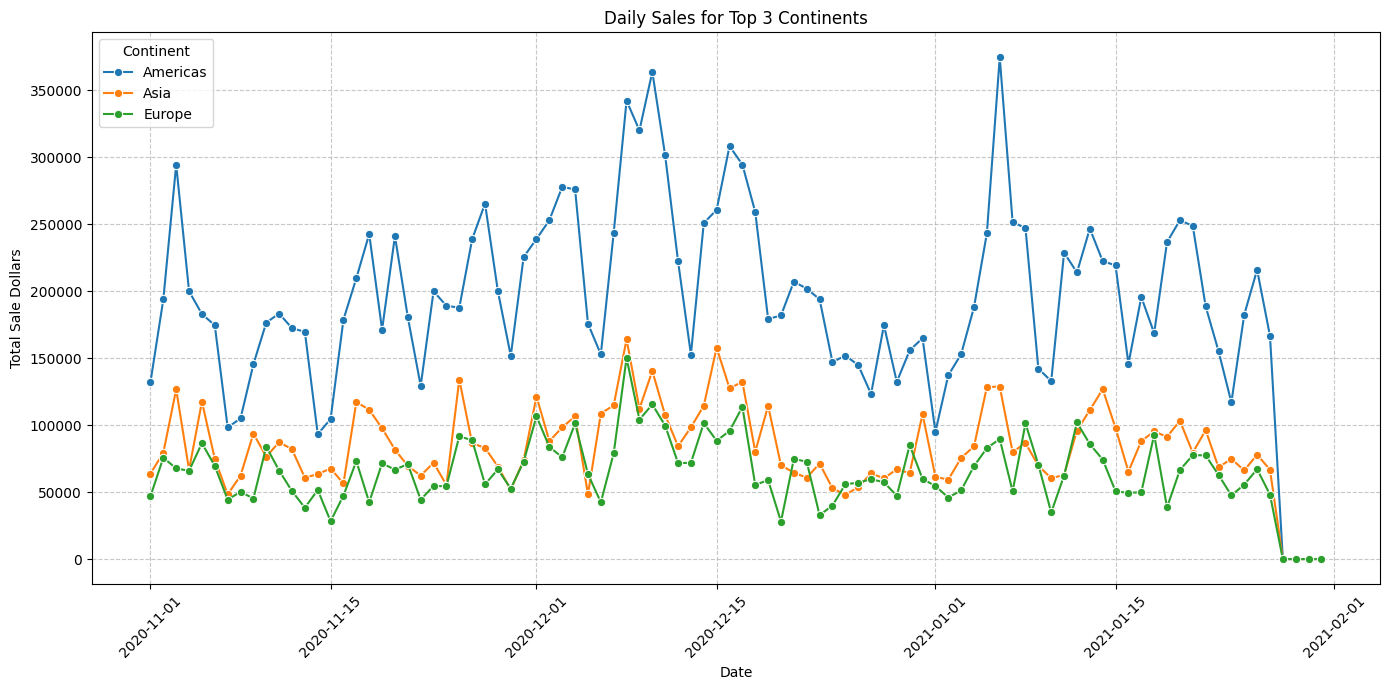

In [43]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sales_top_continents, dashes=False, marker='o')
plt.title('Daily Sales for Top 3 Continents')
plt.xlabel('Date')
plt.ylabel('Total Sale Dollars')
plt.legend(title='Continent', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

All pairwise **correlations** between the top three continents are **strong and positive** (r = 0.768–0.792), with p-values **below 0.001**. This indicates statistically significant relationships between daily sales across these continents: their sales tend to increase and decrease together.


### Analysis of sales correlation between traffic channels

In [44]:
daily_sales_by_traffic_channel = df.groupby(['date', 'traffic_channel'])['price'].sum().unstack().fillna(0)
display(daily_sales_by_traffic_channel.head())

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4


In [45]:
correlation_matrix_traffic_channel = daily_sales_by_traffic_channel.corr(method='pearson')
display(correlation_matrix_traffic_channel)

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000,0.837833,0.814072,0.604060,0.517505
Organic Search,0.837833,1.000000,0.870086,0.583117,0.526068
Paid Search,0.814072,0.870086,1.000000,0.596428,0.521961
Social Search,0.604060,0.583117,0.596428,1.000000,0.455126
Undefined,0.517505,0.526068,0.521961,0.455126,1.000000


In [46]:
# Calculate Pearson correlation coefficient and p-value
# for each pair of traffic channels
for channel_1, channel_2 in combinations(daily_sales_by_traffic_channel.columns, 2):
    r, p_value = pearsonr(
        daily_sales_by_traffic_channel[channel_1],
        daily_sales_by_traffic_channel[channel_2]
    )

    print(
        f"{channel_1} vs {channel_2}: "
        f"r = {r:.3f}, p-value = {p_value:.3f}"
    )

Direct vs Organic Search: r = 0.838, p-value = 0.000
Direct vs Paid Search: r = 0.814, p-value = 0.000
Direct vs Social Search: r = 0.604, p-value = 0.000
Direct vs Undefined: r = 0.518, p-value = 0.000
Organic Search vs Paid Search: r = 0.870, p-value = 0.000
Organic Search vs Social Search: r = 0.583, p-value = 0.000
Organic Search vs Undefined: r = 0.526, p-value = 0.000
Paid Search vs Social Search: r = 0.596, p-value = 0.000
Paid Search vs Undefined: r = 0.522, p-value = 0.000
Social Search vs Undefined: r = 0.455, p-value = 0.000


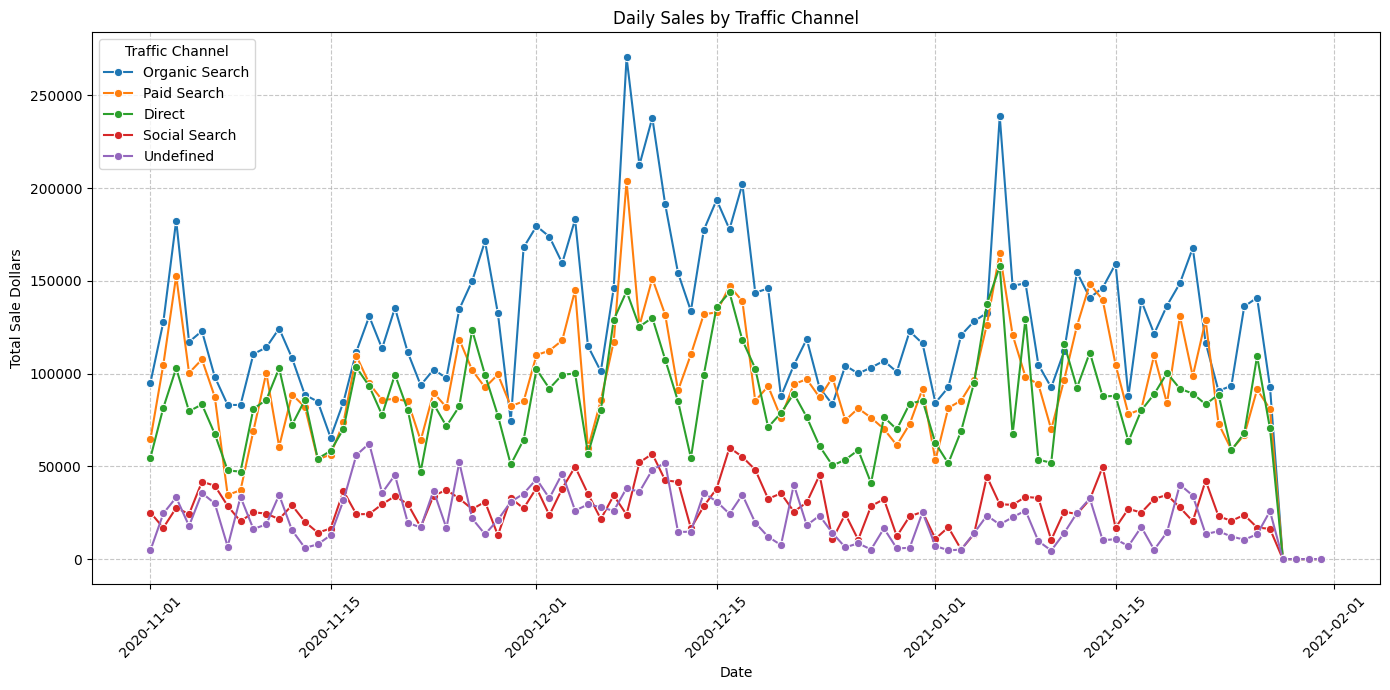

In [47]:
# Calculate total sales per traffic channel to order the legend
traffic_channel_order = daily_sales_by_traffic_channel.sum().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sales_by_traffic_channel, dashes=False, marker='o', hue_order=traffic_channel_order)
plt.title('Daily Sales by Traffic Channel')
plt.xlabel('Date')
plt.ylabel('Total Sale Dollars')
plt.legend(title='Traffic Channel', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

All pairwise correlations between traffic channels are **positive** and **statistically significant** (p < 0.001). The strongest relationships are observed between Organic Search and Paid Search (r = 0.870), Direct and Organic Search (r = 0.838), and Direct and Paid Search (r = 0.814). The weakest, but still moderate, relationship is between Social Search and Undefined traffic (r = 0.455). Overall, daily sales across traffic channels tend to move in the same direction.


### Analysis of sales correlation between top 5 product categories

In [48]:
top_5_product_categories = df.groupby("product_category")["price"].sum().nlargest(5).index
df_top_5_categories = df[df['product_category'].isin(top_5_product_categories)]

daily_sales_top_5_categories = df_top_5_categories.groupby(['date', 'product_category'])['price'].sum().unstack().fillna(0)
display(daily_sales_top_5_categories.head())

product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0


In [49]:
correlation_matrix_top_5_categories = daily_sales_top_5_categories.corr(method='pearson')
display(correlation_matrix_top_5_categories)

product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


In [50]:
# Calculate Pearson correlation coefficient and p-value
# for each pair of top 5 product categories
for category_1, category_2 in combinations(daily_sales_top_5_categories.columns, 2):
    r, p_value = pearsonr(
        daily_sales_top_5_categories[category_1],
        daily_sales_top_5_categories[category_2]
    )

    print(
        f"{category_1} vs {category_2}: "
        f"r = {r:.3f}, p-value = {p_value:.3f}"
    )

Beds vs Bookcases & shelving units: r = 0.593, p-value = 0.000
Beds vs Cabinets & cupboards: r = 0.515, p-value = 0.000
Beds vs Chairs: r = 0.554, p-value = 0.000
Beds vs Sofas & armchairs: r = 0.535, p-value = 0.000
Bookcases & shelving units vs Cabinets & cupboards: r = 0.539, p-value = 0.000
Bookcases & shelving units vs Chairs: r = 0.637, p-value = 0.000
Bookcases & shelving units vs Sofas & armchairs: r = 0.666, p-value = 0.000
Cabinets & cupboards vs Chairs: r = 0.573, p-value = 0.000
Cabinets & cupboards vs Sofas & armchairs: r = 0.658, p-value = 0.000
Chairs vs Sofas & armchairs: r = 0.578, p-value = 0.000


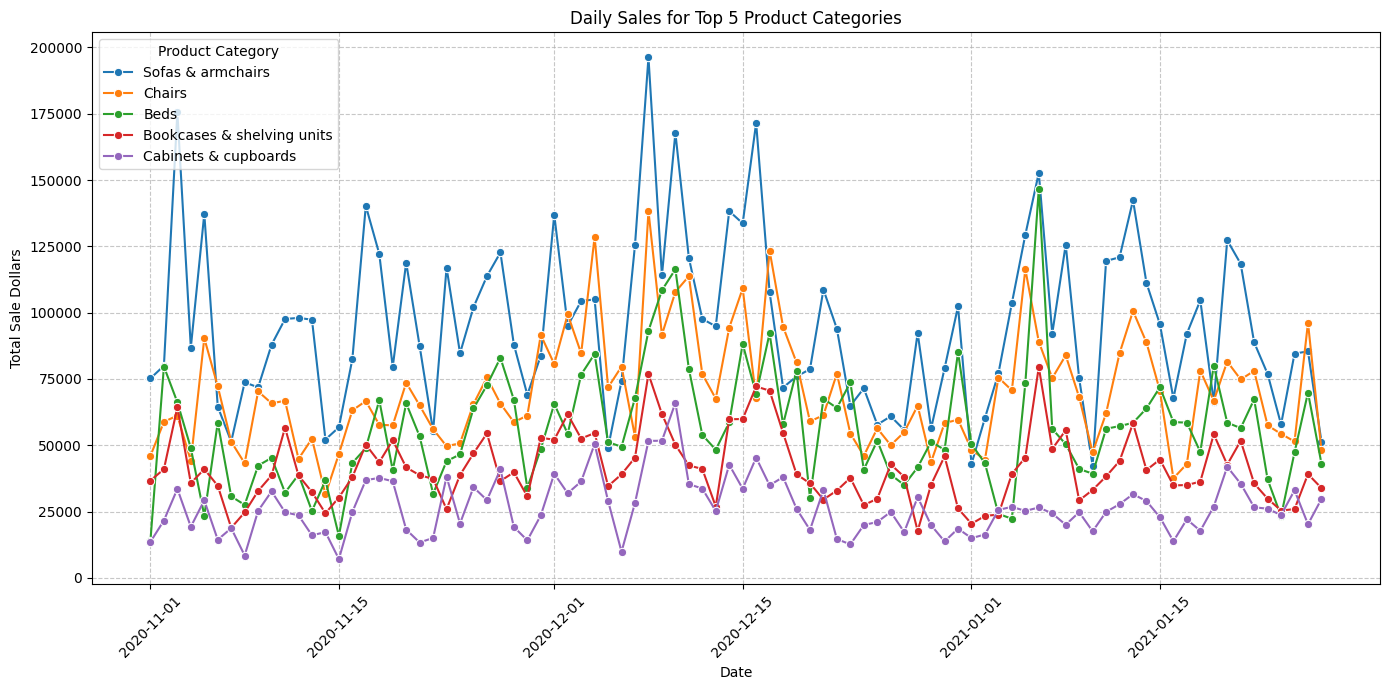

In [51]:
# Calculate total sales per product category to order the legend
category_order = daily_sales_top_5_categories.sum().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sales_top_5_categories, dashes=False, marker='o', hue_order=category_order)
plt.title('Daily Sales for Top 5 Product Categories')
plt.xlabel('Date')
plt.ylabel('Total Sale Dollars')
plt.legend(title='Product Category', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

All pairwise correlations between the top 5 product categories are **positive and statistically significant** (p < 0.001). The relationships are mostly moderate in strength (r = 0.515–0.666), with the strongest correlation observed between Bookcases & shelving units and Sofas & armchairs (r = 0.666). Overall, daily sales across the leading product categories tend to move in the same direction.

### Analysis of sales correlation between device types

In [52]:
daily_sales_by_device_type_unstacked = df.groupby(['date', 'device_type'])['price'].sum().unstack().fillna(0)
display(daily_sales_by_device_type_unstacked.head())

device_type,desktop,mobile,tablet
date,,,
2020-11-01,144445.0,99698.5,149.0
2020-11-02,206727.3,137269.5,11510.0
2020-11-03,304473.8,180602.8,13903.0
2020-11-04,212227.7,118324.4,8635.0
2020-11-05,249682.0,138256.0,3338.6


In [53]:
correlation_matrix_device_type = daily_sales_by_device_type_unstacked.corr(method='pearson')
display(correlation_matrix_device_type)

device_type,desktop,mobile,tablet
device_type,,,
desktop,1.000000,0.873201,0.601354
mobile,0.873201,1.000000,0.567394
tablet,0.601354,0.567394,1.000000


In [54]:
# Calculate Pearson correlation coefficient and p-value
# for each pair of device types
for device_1, device_2 in combinations(daily_sales_by_device_type_unstacked.columns, 2):
    r, p_value = pearsonr(
        daily_sales_by_device_type_unstacked[device_1],
        daily_sales_by_device_type_unstacked[device_2]
    )

    print(
        f"{device_1} vs {device_2}: "
        f"r = {r:.3f}, p-value = {p_value:.3f}"
    )


desktop vs mobile: r = 0.873, p-value = 0.000
desktop vs tablet: r = 0.601, p-value = 0.000
mobile vs tablet: r = 0.567, p-value = 0.000


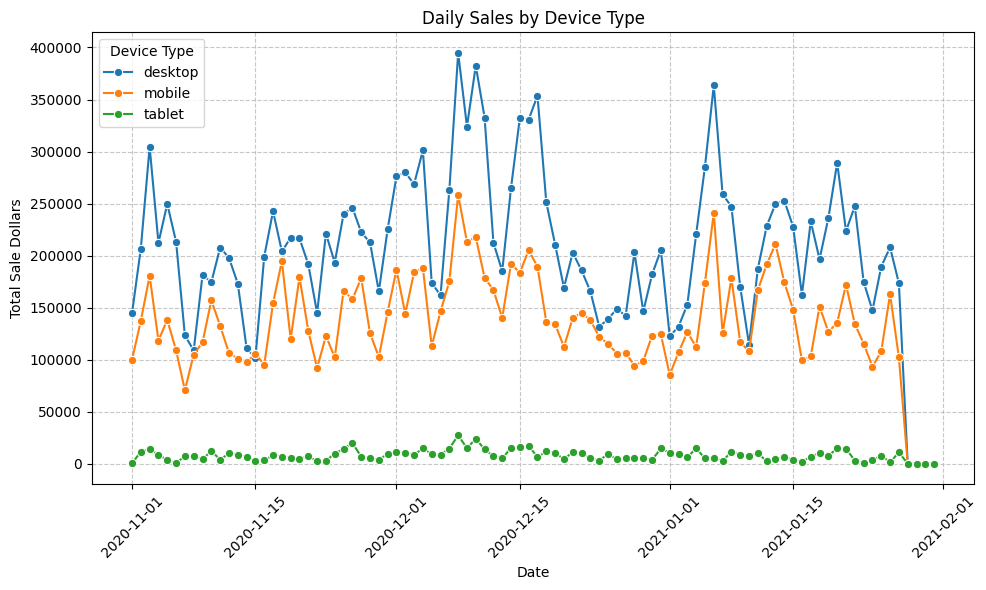

In [55]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=daily_sales_by_device_type_unstacked, dashes=False, marker='o')
plt.title('Daily Sales by Device Type')
plt.xlabel('Date')
plt.ylabel('Total Sale Dollars')
plt.legend(title='Device Type', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

All pairwise correlations between device types are **positive and statistically significant** (p < 0.001). The strongest relationship is observed between desktop and mobile sales (r = 0.873), while desktop–tablet (r = 0.601) and mobile–tablet (r = 0.567) show moderate positive correlations. Overall, daily sales across device types tend to move in the same direction.

## Statistical Analysis of Differences Between Groups

### Sales analysis of registered and unregistered users

In [56]:
# Sales for registered users (where account_id is not NULL)
daily_sales_registered_users = df[df['account_id'].notna()].groupby('date')['price'].sum().reset_index()

# Sales for unregistered users (where account_id is NULL)
daily_sales_unregistered_users = df[df['account_id'].isna()].groupby('date')['price'].sum().reset_index()

display(daily_sales_registered_users.head())
display(daily_sales_unregistered_users.head())

,date,price
0,2020-11-01,21547.0
1,2020-11-02,44956.8
2,2020-11-03,29150.5
3,2020-11-04,20982.2
4,2020-11-05,25334.6


,date,price
0,2020-11-01,222745.5
1,2020-11-02,310550.0
2,2020-11-03,469829.1
3,2020-11-04,318204.9
4,2020-11-05,365942.0


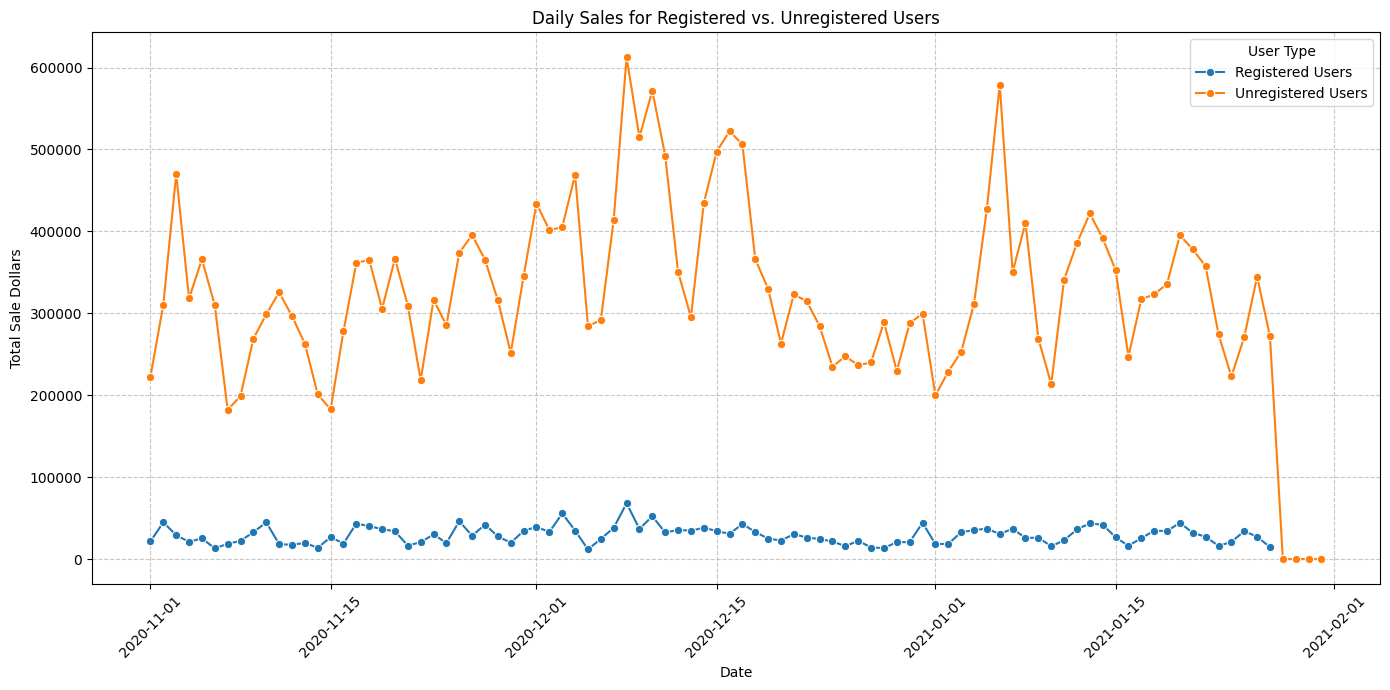

In [57]:
plt.figure(figsize=(14, 7))

sns.lineplot(x='date', y='price', data=daily_sales_registered_users, marker='o', label='Registered Users')
sns.lineplot(x='date', y='price', data=daily_sales_unregistered_users, marker='o', label='Unregistered Users')

plt.title('Daily Sales for Registered vs. Unregistered Users')
plt.xlabel('Date')
plt.ylabel('Total Sale Dollars')
plt.legend(title='User Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpreting sales between registered and non-registered users:**

* **Overall trend:** The graph shows daily sales for both user groups, allowing you to compare their dynamics over time. You can see which group generates more revenue and whether this relationship is changing.
* **Event impact:** Any peaks or troughs in sales can be analyzed for each group separately to understand whether marketing campaigns, holidays, or other events affect registered and non-registered users equally.
* **Dominant group:** The visualization helps you determine which group of users (registered or non-registered) is the main source of revenue for your business.
* **Behavioral differences:** Significant differences in sales dynamics between groups may indicate differences in their behavior or the effectiveness of your acquisition/retention strategies.


### Data distribution and descriptive statistics


In [58]:
print("Descriptive statistics for daily sales of registered users:")
display(daily_sales_registered_users['price'].describe())

print("\nDescriptive statistics for daily sales of unregistered users:")
display(daily_sales_unregistered_users['price'].describe())

Descriptive statistics for daily sales of registered users:


,price
count,88.000000
mean,29346.801136
std,10765.451652
min,11779.000000
25%,20717.375000
50%,28048.000000
75%,35774.700000
max,68151.100000



Descriptive statistics for daily sales of unregistered users:


,price
count,92.000000
mean,319447.963043
std,113764.392969
min,0.000000
25%,263005.700000
50%,315170.750000
75%,375010.750000
max,612358.400000


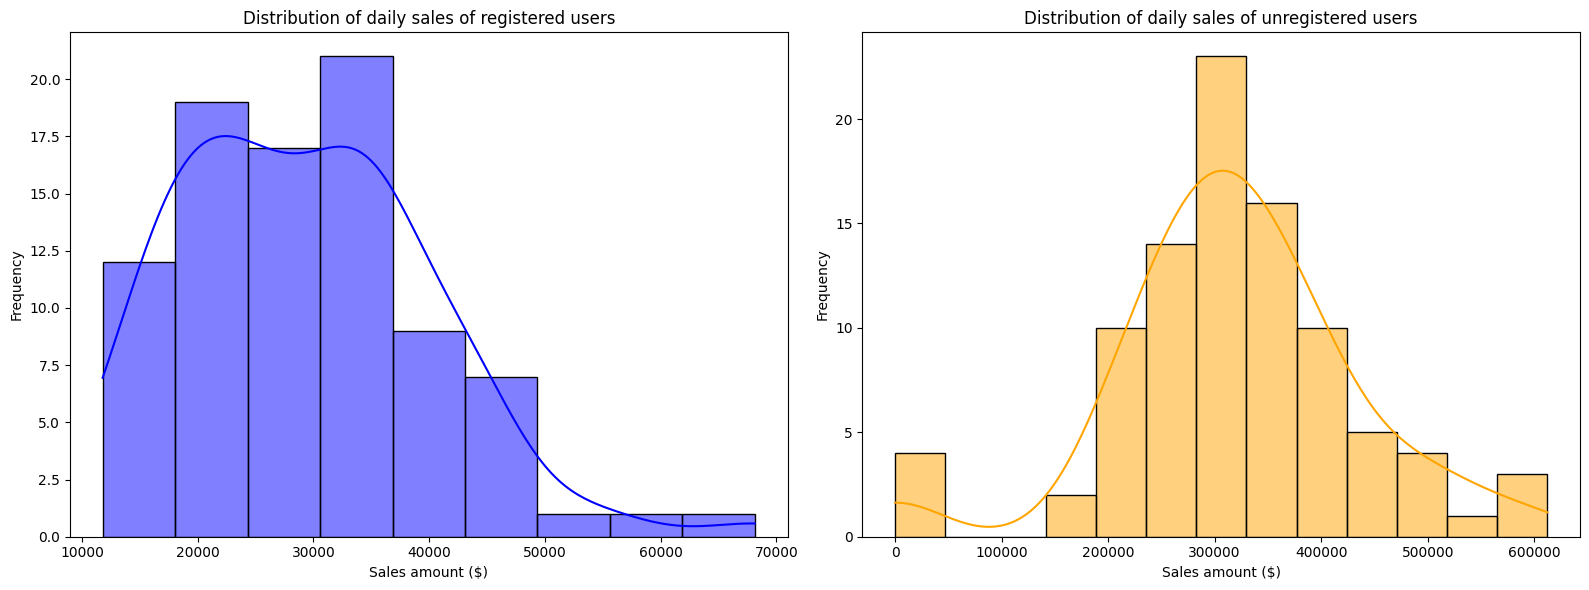

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(daily_sales_registered_users['price'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of daily sales of registered users')
axes[0].set_xlabel('Sales amount ($)')
axes[0].set_ylabel('Frequency')

sns.histplot(daily_sales_unregistered_users['price'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of daily sales of unregistered users')
axes[1].set_xlabel('Sales amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Assumption testing and statistical test selection


In [60]:
# Normality check (Shapiro-Wilk test)
shapiro_registered = shapiro(daily_sales_registered_users['price'])
shapiro_unregistered = shapiro(daily_sales_unregistered_users['price'])

print(f"Shapiro-Wilk test for registered users: W={shapiro_registered.statistic:.3f}, p={shapiro_registered.pvalue:.3f}")
print(f"Shapiro-Wilk test for unregistered users: W={shapiro_unregistered.statistic:.3f}, p={shapiro_unregistered.pvalue:.3f}")

# Checking for equality of variances (Levene's test)
levene_test = levene(daily_sales_registered_users['price'], daily_sales_unregistered_users['price'])

print(f"\nLevene's test for equality of variances: F={levene_test.statistic:.3f}, p={levene_test.pvalue:.3f}")

# Selecting and executing a statistical test
alpha = 0.05

# Due to the large number of zero sales at the end of the period, which distorts the distribution,
# and also due to the differences in the number of days without sales for registered users,
# it is better to use the non-parametric Mann-Whitney U Test, which does not require normality of the distribution.

mannwhitney_stat, mannwhitney_p_val = mannwhitneyu(daily_sales_registered_users['price'], daily_sales_unregistered_users['price'])

print(f"\nMann-Whitney U Test: U={mannwhitney_stat:.3f}, p={mannwhitney_p_val:.3f}")

Shapiro-Wilk test for registered users: W=0.959, p=0.007
Shapiro-Wilk test for unregistered users: W=0.949, p=0.001

Levene's test for equality of variances: F=74.066, p=0.000

Mann-Whitney U Test: U=352.000, p=0.000


### Conclusion on statistical significance


Based on the results of the `Mann-Whitney U Test`:

* **U-statistic:** 352.000
* **P-value:** < 0.001

Since the **p-value (0.000) is less than 0.05 (significance level)**, we can state that there is a **statistically significant difference** in the distribution of daily sales between registered and unregistered users.

**Conclusion:** The results indicate a statistically significant difference in daily sales between registered and unregistered users, with higher daily sales observed for unregistered users in this dataset.

### Analysis of the number of sessions by traffic channels

In [61]:
daily_sessions_by_traffic_channel = df.groupby(['date', 'traffic_channel'])['session_id'].nunique().unstack().fillna(0)
display(daily_sessions_by_traffic_channel.head())

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,608,920,706,214,128
2020-11-02,810,1242,970,315,262
2020-11-03,1216,1871,1367,392,327
2020-11-04,935,1425,1145,368,311
2020-11-05,845,1293,917,346,342


In [62]:
print("Descriptive statistics of daily sessions by traffic channel:")
display(daily_sessions_by_traffic_channel.describe())

Descriptive statistics of daily sessions by traffic channel:


traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
count,92.000000,92.000000,92.000000,92.000000,92.000000
mean,884.586957,1352.445652,1025.445652,303.413043,233.510870
std,220.225267,336.572261,254.421100,88.127923,83.634276
min,481.000000,733.000000,578.000000,137.000000,86.000000
25%,744.000000,1117.250000,860.250000,235.500000,160.750000
50%,869.500000,1329.000000,989.000000,308.000000,229.000000
75%,1004.750000,1558.750000,1171.750000,358.250000,293.250000
max,1668.000000,2589.000000,1959.000000,561.000000,435.000000


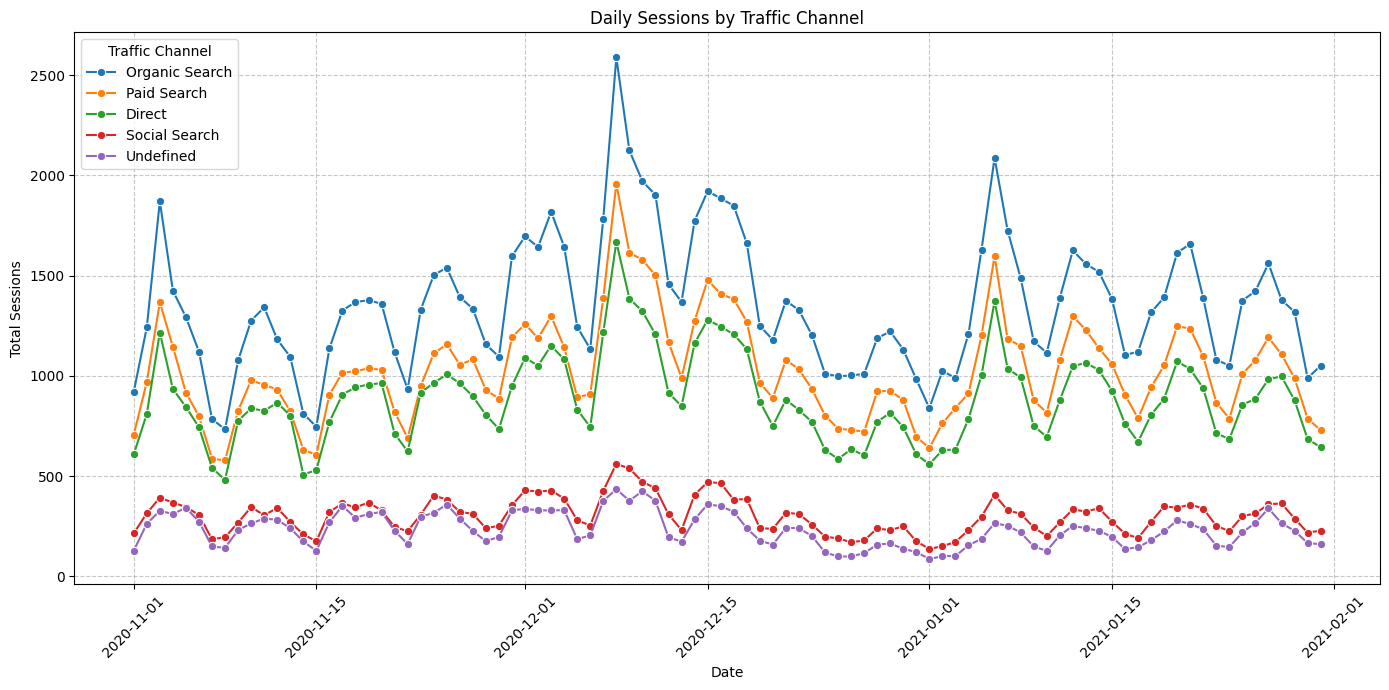

In [63]:
# Calculate total sessions per traffic channel to order the legend
traffic_channel_sessions_order = daily_sessions_by_traffic_channel.sum().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sessions_by_traffic_channel, dashes=False, marker='o', hue_order=traffic_channel_sessions_order)
plt.title('Daily Sessions by Traffic Channel')
plt.xlabel('Date')
plt.ylabel('Total Sessions')
plt.legend(title='Traffic Channel', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
# Normality check for each traffic channel
print("\nShapiro-Wilk test for daily sessions by traffic channels:")
shapiro_results = {}
for column in daily_sessions_by_traffic_channel.columns:
    stat, p = shapiro(daily_sessions_by_traffic_channel[column])
    shapiro_results[column] = {'statistic': stat, 'pvalue': p}
    print(f"  {column}: W={stat:.3f}, p={p:.3f}")

# Check for equality of variances (Levene's test)
print("\nLevene's test for equality of variances for daily sessions by traffic channels:")
levene_stat, levene_p = levene(*[daily_sessions_by_traffic_channel[col] for col in daily_sessions_by_traffic_channel.columns])
print(f"  F={levene_stat:.3f}, p={levene_p:.3f}")

# Since the distributions are not normal and/or the variances are not equal, we use the nonparametric Kruskal-Wallis test
kruskal_stat, kruskal_p = kruskal(*[daily_sessions_by_traffic_channel[col] for col in daily_sessions_by_traffic_channel.columns])

print(f"\nKruskal-Wallis H-test for daily sessions by traffic channels: H={kruskal_stat:.3f}, p={kruskal_p:.3f}")

alpha = 0.05
if kruskal_p < alpha:
    print(f"Since the p-value ({kruskal_p:.3f}) is less than the significance level {alpha}, there is a statistically significant difference in the number of daily sessions between traffic channels.")
else:
    print(f"Since the p-value ({kruskal_p:.3f}) is greater than the significance level {alpha}, no statistically significant differences in the number of daily sessions between traffic channels were found.")


Shapiro-Wilk test for daily sessions by traffic channels:
  Direct: W=0.970, p=0.034
  Organic Search: W=0.964, p=0.012
  Paid Search: W=0.963, p=0.011
  Social Search: W=0.979, p=0.141
  Undefined: W=0.973, p=0.055

Levene's test for equality of variances for daily sessions by traffic channels:
  F=31.753, p=0.000

Kruskal-Wallis H-test for daily sessions by traffic channels: H=368.981, p=0.000
Since the p-value (0.000) is less than the significance level 0.05, there is a statistically significant difference in the number of daily sessions between traffic channels.


### Conclusion on the statistical significance of differences in the number of sessions between traffic channels

Based on the analysis:

* **Normality test (Shapiro-Wilk test):** For most traffic channels (Direct, Organic Search, Paid Search), p-values ​​were less than 0.05, indicating that the distributions of daily sessions **are not normal**. For Social Search (p=0.141) and Undefined (p=0.055), p-values ​​were close to or above 0.05, but the overall picture indicates a violation of normality for most groups.
* **Equality of variances test (Leven's test):** The p-value of the Levene test was **0.000**, which is significantly less than 0.05, indicating **unequal variances** between groups.

Given these results, the **nonparametric Kruskal-Wallis H-test** was chosen to compare the number of daily sessions between different traffic channels, as it does not require assumptions of normality or equality of variances.

* **Kruskal-Wallis test results:**
* **H-statistic:** 368.981
* **P-value:** 0.000

Since the **p-value (0.000) is less than 0.05 (significance level)**, we can say that there is a **statistically significant difference** in the number of daily sessions between at least two traffic channels. This means that the amount of traffic differs significantly depending on the channel.


### Analysis of differences in the share of organic traffic between Europe and America


In [65]:
# Filter data for 'Organic Search' and continents 'Europe' and 'Americas'
df_organic_europe = df[(df['traffic_channel'] == 'Organic Search') & (df['continent'] == 'Europe')]
df_organic_americas = df[(df['traffic_channel'] == 'Organic Search') & (df['continent'] == 'Americas')]

# Total number of unique sessions for 'Organic Search' in Europe and America
sessions_organic_europe = df_organic_europe['session_id'].nunique()
sessions_organic_americas = df_organic_americas['session_id'].nunique()

# Total number of unique sessions (all channels) in Europe and America
sessions_total_europe = df[df['continent'] == 'Europe']['session_id'].nunique()
sessions_total_americas = df[df['continent'] == 'Americas']['session_id'].nunique()

print(f"Number of organic sessions in Europe: {sessions_organic_europe}")
print(f"Total number of sessions in Europe: {sessions_total_europe}")
print(f"Number of organic sessions in America: {sessions_organic_americas}")
print(f"Total number of sessions in America: {sessions_total_americas}")

Number of organic sessions in Europe: 23195
Total number of sessions in Europe: 65135
Number of organic sessions in America: 68671
Total number of sessions in America: 193179


In [66]:
count = [sessions_organic_europe, sessions_organic_americas]
nobs = [sessions_total_europe, sessions_total_americas]

stat, pval = proportions_ztest(count, nobs=nobs)

print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval:.3f}")

alpha = 0.05

if pval < alpha:
    print("\nSince the p-value is less than the significance level (0.05), we reject the null hypothesis.\nThis means that there is a statistically significant difference in the proportion of sessions with organic traffic between Europe and America.")
else:
    print("\nSince the p-value is greater than the significance level (0.05), we cannot reject the null hypothesis.\nThis means that there is no statistically significant difference in the proportion of sessions with organic traffic between Europe and America.")

Z-statistic: 0.290
P-value: 0.772

Since the p-value is greater than the significance level (0.05), we cannot reject the null hypothesis.
This means that there is no statistically significant difference in the proportion of sessions with organic traffic between Europe and America.


### Sales analysis by device type


In [67]:
print("Descriptive statistics of daily sales by device type:")
display(daily_sales_by_device_type_unstacked.describe())

Descriptive statistics of daily sales by device type:


device_type,desktop,mobile,tablet
count,92.000000,92.000000,92.000000
mean,205043.902174,134611.150000,7863.764130
std,76352.784599,47319.681091,5267.686302
min,0.000000,0.000000,0.000000
25%,165616.175000,106667.700000,4036.500000
50%,206009.900000,129988.550000,7036.000000
75%,247152.175000,168160.775000,10615.750000
max,394823.700000,258433.800000,27252.000000


In [68]:
# Normality check for each device type
print("\nShapiro-Wilk test for daily sales by device type:")
shapiro_results_device = {}
for column in daily_sales_by_device_type_unstacked.columns:
    stat, p = shapiro(daily_sales_by_device_type_unstacked[column])
    shapiro_results_device[column] = {'statistic': stat, 'pvalue': p}
    print(f"  {column}: W={stat:.3f}, p={p:.3f}")

# Test for equality of variances (Levene's test)
print("\nLevene's test for equality of variances for daily sales by device type:")
levene_stat_device, levene_p_device = levene(*[daily_sales_by_device_type_unstacked[col] for col in daily_sales_by_device_type_unstacked.columns])
print(f"  F={levene_stat_device:.3f}, p={levene_p_device:.3f}")

# Since the distributions are not normal and/or the variances are not equal, we use the nonparametric Kruskal-Wallis test
kruskal_stat_device, kruskal_p_device = kruskal(*[daily_sales_by_device_type_unstacked[col] for col in daily_sales_by_device_type_unstacked.columns])

print(f"\nKruskal-Wallis H-test for daily sales by device type: H={kruskal_stat_device:.3f}, p={kruskal_p_device:.3f}")

alpha = 0.05
if kruskal_p_device < alpha:
    print(f"Since the p-value ({kruskal_p_device:.3f}) is less than the significance level {alpha}, there is a statistically significant difference in the number of daily sales between device types.")
else:
    print(f"Since the p-value ({kruskal_p_device:.3f}) is greater than the significance level {alpha}, no statistically significant differences in the number of daily sales between device types were found.")


Shapiro-Wilk test for daily sales by device type:
  desktop: W=0.963, p=0.010
  mobile: W=0.943, p=0.001
  tablet: W=0.943, p=0.001

Levene's test for equality of variances for daily sales by device type:
  F=50.025, p=0.000

Kruskal-Wallis H-test for daily sales by device type: H=178.030, p=0.000
Since the p-value (0.000) is less than the significance level 0.05, there is a statistically significant difference in the number of daily sales between device types.


## Analytical Dashboard in Tableau Public


https://public.tableau.com/app/profile/andrii.klymchuk/viz/E-commercePerformance_17856766576670/E-commerce?publish=yes

In [69]:
from IPython.display import IFrame

tableau_url = "https://public.tableau.com/views/E-commercePerformance_17856766576670/E-commerce?:showVizHome=no&:embed=yes"

IFrame(tableau_url, width=1700, height=950)